This notebook demonstrates how to perform post processing for EH-Drift output. Tools libray contains the necessory functions required for the analysis.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
plt.style.use('default')
import matplotlib
import pandas as pd
import os
import re
from tqdm import tqdm
from dspeed.processors.trap_filters import trap_norm
from tools import load_waveform_data, compute_pickoff_values_and_plot_random, add_tail_slope_to_dataframe,calculate_tail_slope, query_and_plot_waveform
color_array=np.linspace(0,1,11)
cmap = plt.cm.tab20b

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>")) #makes the notebook wider
plt.style.use('default')
import h5py


#set the detector name and inout conditions for the trap filter
detector = 'P00698A' # 'ICPC' 'P00698A' 'P42575A' 'UNC_scanner' 'ponama_1' 'V00048A' 'P00749A' 'P00661B' 'V02166B'
sim_time=16000
step_time_out = 16
rise = 10000 
flat = 3000
pickoff = 13000



#directory at which the waveforms are located
directory = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/{detector}'
time = np.linspace(start=step_time_out, stop= sim_time, num= (int) (sim_time/step_time_out))

In [2]:
# Loads the waveforms into a pandas df
waveforms_df = load_waveform_data(directory)
print(waveforms_df.columns)


100%|██████████| 1/1 [00:01<00:00,  1.37s/it]

Index(['r', 'z', 'eng', 'sc', 'sf_drift', 'grid', 'pass_thickness',
       'self_repulsion', 'det', 'wf'],
      dtype='object')


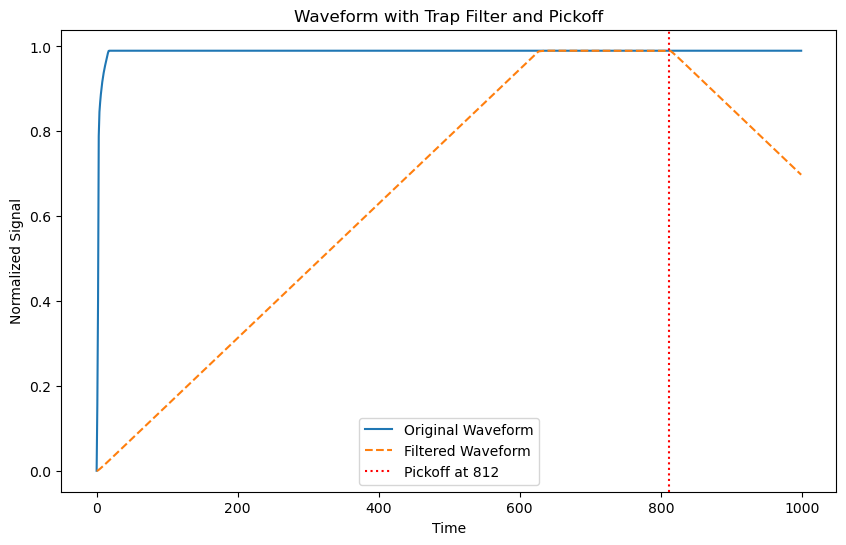

In [3]:
# Apply Trap filter to all waveforms in the df
activeness = compute_pickoff_values_and_plot_random(waveforms_df, rise_samp := math.floor(rise/step_time_out), flat_samp := math.floor(flat/step_time_out), pickoff_samp := math.floor(pickoff/step_time_out), plot_random=True)

100%|██████████| 2187/2187 [00:00<00:00, 14809.69it/s]


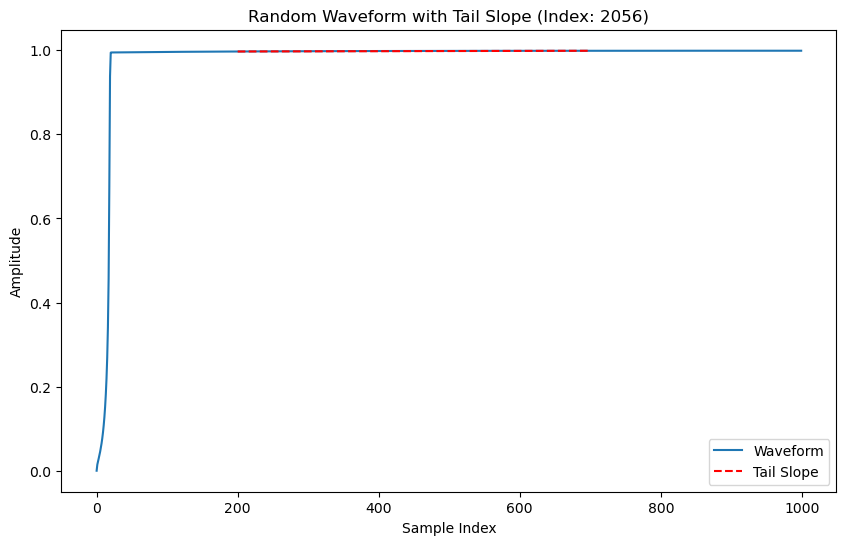

Index(['r', 'z', 'eng', 'sc', 'sf_drift', 'grid', 'pass_thickness',
       'self_repulsion', 'det', 'wf', 'energy_estimate', 'tail_slope'],
      dtype='object')


In [4]:
# Calculate and add tail slope to data frame
ti = 200
tf = 700
window = 100
# Assuming waveforms_df is your DataFrame with waveforms in 'wf' column
add_tail_slope_to_dataframe(waveforms_df, ti, tf, window, plot_random_waveform=True)
print(waveforms_df.columns)

In [5]:
#at this point you can use the waveforms_df to save the map to any format file
print(waveforms_df.columns)

Index(['r', 'z', 'eng', 'sc', 'sf_drift', 'grid', 'pass_thickness',
       'self_repulsion', 'det', 'wf', 'energy_estimate', 'tail_slope'],
      dtype='object')


In [6]:
waveforms_df.head()

,r,z,eng,sc,sf_drift,grid,pass_thickness,self_repulsion,det,wf,energy_estimate,tail_slope
0,2.0,0.02,2039.0,-0.3,0.001,0.02,0.002,0,P00698A,"[0.0, 0.43433358444466863, 0.5745738360419892,...",0.995335,0.000010
1,5.0,0.02,2039.0,-0.3,0.001,0.02,0.002,0,P00698A,"[0.0, 0.1260881679377369, 0.21491763224742366,...",0.581561,0.000266
2,8.0,0.02,2039.0,-0.3,0.001,0.02,0.002,0,P00698A,"[0.0, 0.05594099402196245, 0.09611814720947844...",0.284664,0.000090
3,11.0,0.02,2039.0,-0.3,0.001,0.02,0.002,0,P00698A,"[0.0, 0.033660364283117264, 0.0583126865020902...",0.175500,0.000045
4,14.0,0.02,2039.0,-0.3,0.001,0.02,0.002,0,P00698A,"[0.0, 0.0230370822984676, 0.04041862891331882,...",0.118360,0.000028


In [7]:
import os
import pandas as pd

# Ensure activeness is correctly assigned from `energy_estimate`
waveforms_df['activeness'] = waveforms_df['energy_estimate']

# Offset z so that the top surface becomes z = 0
z_offset = waveforms_df['z'].max()
waveforms_df['z'] = z_offset - waveforms_df['z']

# Define the columns for output and their desired header labels
output_columns = ['r', 'z', 'eng', 'activeness']
header_labels = ['r (mm)', 'z (mm)', 'eng (keV)', 'activeness']

# Iterate over unique detector names and sc values
for det in waveforms_df['det'].unique():
    for sc in waveforms_df['sc'].unique():
        # Filter data for this specific combination
        subset_df = waveforms_df[(waveforms_df['det'] == det) & (waveforms_df['sc'] == sc)]

        # Skip empty datasets
        if subset_df.empty:
            continue

        # Create directory structure (det/sc=value/)
        directory = f"/nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/{det}/sc={sc}"
        os.makedirs(directory, exist_ok=True)

        # Define output file path with det and sc value in filename
        file_path = os.path.join(directory, f"activeness_map_{det}_sc={sc}.txt")

        # Select and round relevant columns
        formatted_df = subset_df[output_columns].copy()
        formatted_df['r'] = formatted_df['r'].round(3)
        formatted_df['z'] = formatted_df['z'].round(3)
        formatted_df['eng'] = formatted_df['eng'].round(3)

        # Rename columns
        formatted_df.columns = header_labels

        # Save to file
        formatted_df.to_csv(file_path, index=False)

        print(f"Saved: {file_path}")


Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=-0.3/activeness_map_P00698A_sc=-0.3.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=0.3/activeness_map_P00698A_sc=0.3.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=0.0/activeness_map_P00698A_sc=0.0.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=-0.03/activeness_map_P00698A_sc=-0.03.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=0.03/activeness_map_P00698A_sc=0.03.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=-0.15/activeness_map_P00698A_sc=-0.15.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=0.15/activeness_map_P00698A_sc=0.15.txt
Saved: /nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input/P00698A/sc=-0.5/activeness_map_P00698A_sc=-0.5.txt


In [8]:
#Zip the file, mkaing it easier to download
import shutil

folder_path = "/nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input" 
zip_path = "/nas/longleaf/home/kbhimani/EH-Drift/Analysis/mpp_input.zip"

folder_path = "/nas/longleaf/home/kbhimani/EH-Drift"
zip_path = "/nas/longleaf/home/kbhimani/EH-Drift.zip"

# Compress the folder
shutil.make_archive(zip_path.replace(".zip", ""), 'zip', folder_path)

print("Folder zipped successfully!")


Folder zipped successfully!


In [9]:
#Example of how to filter the waveform_df to view it
print(waveforms_df[(waveforms_df["sc"]==-0.3) & (waveforms_df["z"]==0.04) & (waveforms_df["eng"]==2039)])

Empty DataFrame
Columns: [r, z, eng, sc, sf_drift, grid, pass_thickness, self_repulsion, det, wf, energy_estimate, tail_slope, activeness]
Index: []


In [10]:
#Here's an example on how to query a waveform from the dataframe and plot it

time = np.linspace(start=step_time_out, stop= sim_time, num= (int) (sim_time/step_time_out))
# Example call to the function
r_exp= 14.00
z_exp= 0.04
sc_exp=-0.3
sd_exp = 0.001
eng_exp=2039.00
det_exp=detector
grid_exp=0.02
specific_waveform = query_and_plot_waveform(waveforms_df, time, r_exp, z_exp, sc_exp, sd_exp, eng_exp, det_exp, grid_exp)
# cut=((time>100) & (time <160))
if specific_waveform.any():
    plt.plot(time, specific_waveform)
    plt.xlabel('Time (ns)', fontsize=16)
    plt.ylabel('Normalized Signal', fontsize=16)
    plt.title(f'Signal at r={r_exp}, z={z_exp}, sc={sc_exp}, sd={sd_exp}, eng={eng_exp}') #, det={det_exp}, grid={grid_exp}

    # Adjust ticks for better visibility
    plt.xticks(fontsize=12)  # Bigger tick labels
    plt.yticks(fontsize=12)  # Bigger tick labels

    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.minorticks_on()
    plt.grid(which='minor', linestyle=':', linewidth='0.5')
    plt.show()

No waveform found matching the criteria.


AttributeError: 'NoneType' object has no attribute 'any'

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

# Specify the r values to include in the plot
# allowed_r_values = [1.0, 2.0, 3.0, 4.0, 5.0, 8.0, 11.0, 14.0, 17.0, 20.0, 23.0, 26.0, 29.0]

# Filter parameters
filter_det = detector
filter_sc = -0.3
filter_eng = 2039 
filter_sd = 0.001
v_min=0
v_max=1
# Apply filter to DataFrame
filtered_df = waveforms_df[
    (waveforms_df['det'] == filter_det) & 
    (waveforms_df['sc'] == filter_sc) & 
    (waveforms_df['eng'] == filter_eng) &
    # (waveforms_df['r'] > 4) &
    (waveforms_df['sf_drift'] == filter_sd)
]

# Further filter to only include the specified r values
# filtered_df = filtered_df[filtered_df['r'].isin(allowed_r_values)]

# Extracting r, z, and energy estimate for plotting
r_plot = filtered_df['r'].to_numpy()
z_plot = filtered_df['z'].to_numpy()
energy_estimate = filtered_df['energy_estimate'].to_numpy()  # Adjust this if 'energy_estimate' is not the correct column

# Ensure all energy_estimate values are within the range 0 to 1
energy_estimate = np.clip(energy_estimate, 0, 1)

# Create scatter plot
plt.figure(figsize=(10, 6))
sc = plt.scatter(r_plot, z_plot, c=energy_estimate, cmap=cm.viridis, s=9, vmin=v_min, vmax=v_max)  # Fixed color scale
cbar = plt.colorbar(sc)
cbar.set_label('Energy Estimate (Normalized)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.xlabel('Radius (mm)', fontsize=14)
plt.ylabel('Height (mm)', fontsize=14)
plt.title(f'Activeness Map for {filter_det} Detector with Linear Interpolation \n Initial Energy={filter_eng}KeV, Surface Charge={filter_sc}', fontsize=16)
plt.show()


In [ ]:
#!/usr/local/bin/python3
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.path import Path
import math
from scipy.interpolate import griddata

from tools import (
    load_waveform_data,
    compute_pickoff_values_and_plot_random
)

# ---------------- USER-DEFINED VARIABLES ----------------
int_method    = 'cubic'       # 'linear', 'cubic', or 'nearest'
detector      = 'ponama_1'
sim_time      = 16000
step_time_out = 16
rise          = 10000
flat          = 3000
pickoff       = 13000
filter_sc     = -0.3          # surface charge
filter_eng    = 5000          # initial energy
filter_sd     = 0.001         # surface drift factor

# Linear color-scale bounds
v_min_lin = 0.0
v_max_lin = 1.00
# --------------------------------------------------------

# Directory where waveforms are stored
directory = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/{detector}'

# Create a time array
time = np.linspace(start=step_time_out, stop=sim_time, num=int(sim_time/step_time_out))

# 1) Load waveforms
waveforms_df = load_waveform_data(directory)

# 2) Compute pickoff values
rise_samp    = math.floor(rise / step_time_out)
flat_samp    = math.floor(flat / step_time_out)
pickoff_samp = math.floor(pickoff / step_time_out)
activeness_df = compute_pickoff_values_and_plot_random(
    waveforms_df,
    rise   = rise_samp,
    flat   = flat_samp,
    pickoff= pickoff_samp,
    plot_random=False
)

# 3) Filter the DataFrame
filtered_df = waveforms_df[
    (waveforms_df['det']      == detector) &
    (waveforms_df['sc']       == filter_sc) &
    (waveforms_df['eng']      == filter_eng) &
    (waveforms_df['sf_drift'] == filter_sd)
]

# 4) Extract r, z, and energy
r_plot = filtered_df['r'].to_numpy()
z_plot = filtered_df['z'].to_numpy()
energy_estimate = filtered_df['energy_estimate'].to_numpy()

# 5) Prepare interpolation grid
grid_size = 500
r_lin = np.linspace(r_plot.min(), r_plot.max(), grid_size)
z_lin = np.linspace(z_plot.min(), z_plot.max(), grid_size)
r_grid, z_grid = np.meshgrid(r_lin, z_lin)

# 6) Interpolate
if len(r_plot) <= 2:
    print("Not enough points for interpolation. Exiting.")
    exit(1)

energy_interp = griddata(
    (r_plot, z_plot),
    energy_estimate,
    (r_grid, z_grid),
    method=int_method
)

# 7) Clip values to [0, 1]
energy_interp_adjusted = energy_interp[:-1, :-1]
energy_interp_clipped  = np.clip(energy_interp_adjusted, v_min_lin, v_max_lin)

# 8) Apply triangular mask
triangle_vertices = np.array([[28, 0], [32, 0], [32, 2.5]])
path  = Path(triangle_vertices)
points= np.c_[r_grid.ravel(), z_grid.ravel()]
mask  = path.contains_points(points).reshape(r_grid.shape)[:-1, :-1]
energy_interp_masked = np.ma.array(energy_interp_clipped, mask=mask)

# 9) Plot
plt.figure(figsize=(10, 6))
norm_obj = matplotlib.colors.Normalize(vmin=v_min_lin, vmax=v_max_lin)

heatmap = plt.pcolormesh(
    r_grid[:-1, :-1],
    z_grid[:-1, :-1],
    energy_interp_masked,
    cmap=cm.viridis,
    norm=norm_obj,
    shading='auto'
)

cbar = plt.colorbar(heatmap)
cbar.set_label("Activeness", fontsize=14)
cbar.ax.tick_params(labelsize=12)
plt.xlabel('Radius (mm)', fontsize=14)
plt.ylabel('Height (mm)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim([z_plot.min(), z_plot.max()])
plt.xlim([r_plot.min(), r_plot.max()])

# 10) Save figure with '_linear_full' suffix
fname_out = f"figs/activeness_map_{int_method}_sc={filter_sc}_{detector}_{filter_eng}_linear_full.png"
plt.savefig(fname_out, dpi=100)
plt.show()


In [ ]:
#Example map for ICPC detectors, for clarity we add mask for the ditch and n+ region, change that according to the detector
#!/usr/local/bin/python3
import os
import math
import numpy as np
import matplotlib
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Rectangle, Polygon
from scipy.interpolate import griddata

# Project-specific imports
from tools import (
    load_waveform_data,
    compute_pickoff_values_and_plot_random
)

# ---------------- USER-DEFINED VARIABLES ----------------
int_method    = 'cubic'     # 'linear', 'cubic', 'nearest'
detector      = 'V07647A'
sim_time      = 16000
step_time_out = 16
rise          = 10000
flat          = 3000
pickoff       = 13000
filter_sc     = -0.30
filter_eng    = 5000
filter_sd     = 0.001

# Define linear color scale
v_min_lin = 0.9
v_max_lin = 1.0
# --------------------------------------------------------

# Directory where waveforms are stored
directory = f'/nas/longleaf/home/kbhimani/EH-Drift/waveforms/{detector}'

# Time array
time = np.linspace(start=step_time_out, stop=sim_time, num=int(sim_time/step_time_out))

# Load waveforms
waveforms_df = load_waveform_data(directory)

rise_samp     = math.floor(rise / step_time_out)
flat_samp     = math.floor(flat / step_time_out)
pickoff_samp  = math.floor(pickoff / step_time_out)
activeness_df = compute_pickoff_values_and_plot_random(
    waveforms_df,
    rise   = rise_samp,
    flat   = flat_samp,
    pickoff= pickoff_samp,
    plot_random=False
)

# Filter the DataFrame
filtered_df = waveforms_df[
    (waveforms_df['det']      == detector) &
    (waveforms_df['sc']       == filter_sc) &
    (waveforms_df['eng']      == filter_eng) &
    (waveforms_df['sf_drift'] == filter_sd)
]

r_plot = filtered_df['r'].to_numpy()
z_plot = filtered_df['z'].to_numpy()
energy_estimate = filtered_df['energy_estimate'].to_numpy()

# Create a grid for interpolation
grid_size = 500
r_lin = np.linspace(r_plot.min(), r_plot.max(), grid_size)
z_lin = np.linspace(z_plot.min(), z_plot.max(), grid_size)
r_grid, z_grid = np.meshgrid(r_lin, z_lin)

# Interpolate
if len(r_plot) > 2:
    energy_interp = griddata(
        (r_plot, z_plot),
        energy_estimate,
        (r_grid, z_grid),
        method=int_method
    )
else:
    print("Not enough points for interpolation. Exiting.")
    exit(1)

# Clip array to [0,1]
energy_interp_adjusted = energy_interp[:-1, :-1]
energy_interp_clipped  = np.clip(energy_interp_adjusted, v_min_lin, v_max_lin)

# ---------------- PLOTTING ----------------
plt.figure(figsize=(10, 6))

norm_obj = colors.Normalize(vmin=v_min_lin, vmax=v_max_lin)

cbar_label = 'Activeness'

heatmap = plt.pcolormesh(
    r_grid[:-1, :-1],
    z_grid[:-1, :-1],
    energy_interp_clipped,
    cmap=cm.viridis,
    norm=norm_obj,
    shading='auto'
)
cbar = plt.colorbar(heatmap)
cbar.set_label(cbar_label, fontsize=14)
cbar.ax.tick_params(labelsize=12)
plt.xlabel('Radius (mm)', fontsize=14)
plt.ylabel('Height (mm)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Overlay excluded areas as rectangles
excluded_areas = [((11.5, 0.), (15, 2.2))]
for (r_start, z_start), (r_end, z_end) in excluded_areas:
    plt.gca().add_patch(Rectangle(
        (r_start, z_start),
        r_end - r_start,
        z_end - z_start,
        color='white', zorder=2
    ))

excluded_areas2 = [((15, 0.), (39.8, 1.2))]
for (r_start, z_start), (r_end, z_end) in excluded_areas2:
    plt.gca().add_patch(Rectangle(
        (r_start, z_start),
        r_end - r_start,
        z_end - z_start,
        color='white', zorder=2
    ))

plt.xlim([r_plot.min(), r_plot.max()])
plt.ylim([z_plot.min(), z_plot.max()])

# Build output filename
fname_out = f"figs/activeness_map_{int_method}_sc={filter_sc}_{detector}_{filter_eng}_linear_full.png"

plt.savefig(fname_out, dpi=100)
plt.show()